# Capstone Project | Employee Retention Prediction
---
**Objective:** Employee attrition is one of the biggest challenges in the tech industry, especially when skilled professionals like Data Scientists leave unexpectedly. In this project, I used HR data to build a machine learning model that predicts whether a Data Scientist is likely to look for a new job.

The main objective of this project is to help companies move from a reactive approach to a proactive strategy. Instead of responding after an employee resigns, organizations can identify potential job change risks early and take preventive action.

By predicting attrition in advance, companies can improve employee retention, plan recruitment more effectively, and invest wisely in employee development. This project demonstrates how data-driven insights can help businesses make smarter workforce decisions and gain a competitive advantage.

**Dataset:** HR Analytics – Job Change of Data Scientists

**Target Variable:** `target` → 1 = Looking for a job change | 0 = Not looking

---
## Table of Contents
1. [Import Libraries](#step1)
2. [Read Dataset](#step2)
3. [Dataset Overview](#step3)
   - 3.1 [Dataset Basic Information](#step31)
   - 3.2 [Summary Statistics – Numerical Features](#step32)
   - 3.3 [Summary Statistics – Categorical Features](#step33)
4. [EDA – Exploratory Data Analysis](#step4)
   - 4.1 [Univariate Analysis](#step41)
     - 4.1.1 [Numerical Variables](#step411)
     - 4.1.2 [Categorical Variables](#step412)
   - 4.2 [Bivariate Analysis](#step42)
     - 4.2.1 [Numerical Features vs Target](#step421)
     - 4.2.2 [Categorical Features vs Target](#step422)
5. [Data Preprocessing](#step5)
   - 5.1 [Irrelevant Features Removal](#step51)
   - 5.2 [Missing Value Treatment](#step52)
   - 5.3 [Outlier Treatment](#step53)
   - 5.4 [Categorical Feature Encoding](#step54)
   - 5.5 [Feature Scaling](#step55)
   - 5.6 [Handling Class Imbalance – SMOTE](#step56)
6. [Logistic Regression Model](#step6)
   - 6.1 [LR Base Model](#step61)
   - 6.2 [LR Hyperparameter Tuning](#step62)
   - 6.3 [LR Model Evaluation](#step63)
7. [Random Forest Model](#step7)
   - 7.1 [RF Base Model](#step71)
   - 7.2 [RF Hyperparameter Tuning](#step72)
   - 7.3 [RF Model Evaluation](#step73)
8. [XGBoost Model](#step8)
   - 8.1 [XGB Base Model](#step81)
   - 8.2 [XGB Hyperparameter Tuning](#step82)
   - 8.3 [XGB Model Evaluation](#step83)
9. [LightGBM Model](#step9)
   - 9.1 [LGBM Base Model](#step91)
   - 9.2 [LGBM Hyperparameter Tuning](#step92)
   - 9.3 [LGBM Model Evaluation](#step93)
10. [Model Comparison](#step10)
11. [Feature Importance](#step11)
12. [Conclusion](#step12)
13. [Prediction on Test Data](#step13)


## Step 1 | Import Libraries <a id='step1'></a>
---
[Table of Contents](#)

We begin by importing all necessary libraries for data manipulation, visualization, preprocessing, and model building.

In [16]:
# ── Data Manipulation ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             classification_report, ConfusionMatrixDisplay)

# ── Imbalanced Data ───────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Machine Learning Models ───────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
!pip install xgboost
!pip install lightgbm
# ── Settings ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 | Read Dataset <a id='step2'></a>
---
[Table of Contents](#)

We load the training and test datasets. The training set contains the labeled data (with `target` column) used for model building. The test set is used for final predictions.

In [17]:
# Load training and test data
df      = pd.read_csv('aug_train.csv')
df_test = pd.read_csv('aug_test.csv')

print(f'Training Set Shape : {df.shape}')
print(f'Test Set Shape      : {df_test.shape}')
print()
df.head()

Training Set Shape : (19158, 14)
Test Set Shape      : (2129, 13)



,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## Step 3 | Dataset Overview <a id='step3'></a>
---
[Table of Contents](#)

In this step we get a high-level understanding of the dataset — its shape, data types, missing values, and class distribution.

### Step 3.1 | Dataset Basic Information <a id='step31'></a>
---
[Table of Contents](#)

In [18]:
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
print()
print('Data Types:')
print(df.dtypes)
print()
print('Missing Values:')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Count': missing, 'Percentage(%)': missing_pct})[missing > 0])

Rows    : 19158
Columns : 14

Data Types:
enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object

Missing Values:
                     Count  Percentage(%)
gender                4508          23.53
enrolled_university    386           2.01
education_level        460           2.40
major_discipline      2813          14.68
experience              65           0.34
company_size          5938          30.99
company_type          6140          32.05
last_new_job           423           2.21


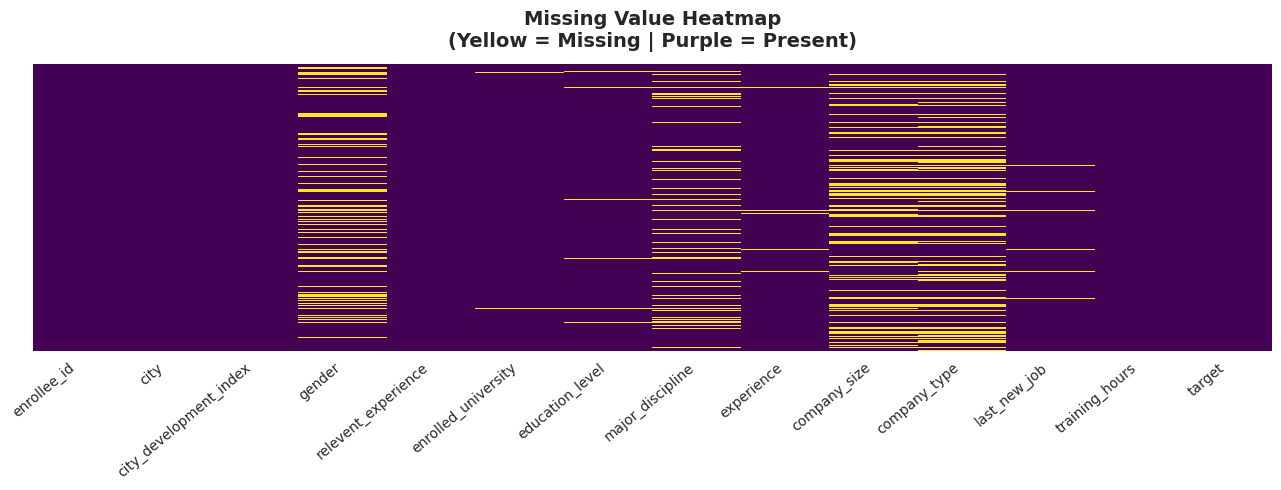

In [19]:
# ── Missing Value Heatmap ─────────────────────────────────────────────────────
plt.figure(figsize=(13, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap\n(Yellow = Missing | Purple = Present)',
          fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

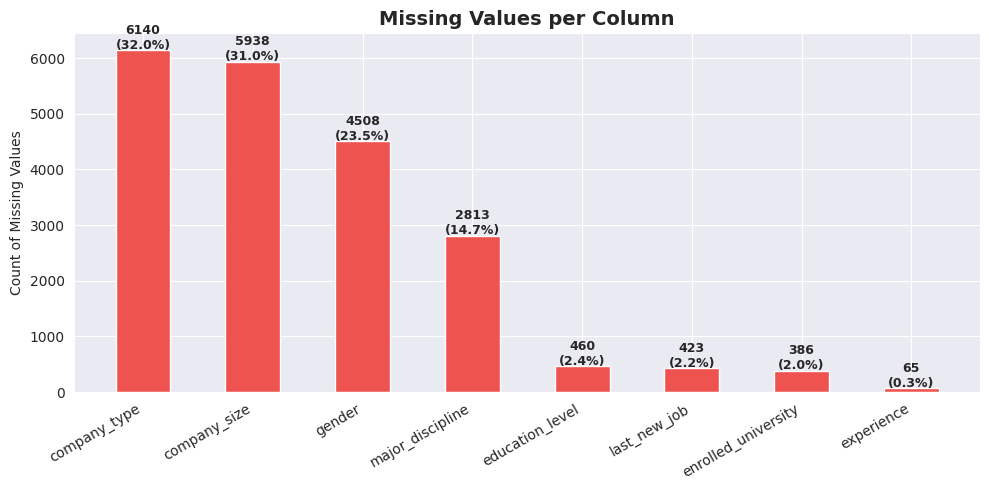

In [20]:
# ── Missing Values per Column – Bar Chart ────────────────────────────────────
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(missing_data.index, missing_data.values,
              color='#EF5350', edgecolor='white', width=0.5)
for bar, val in zip(bars, missing_data.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Missing Values per Column', fontsize=14, fontweight='bold')
ax.set_ylabel('Count of Missing Values')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

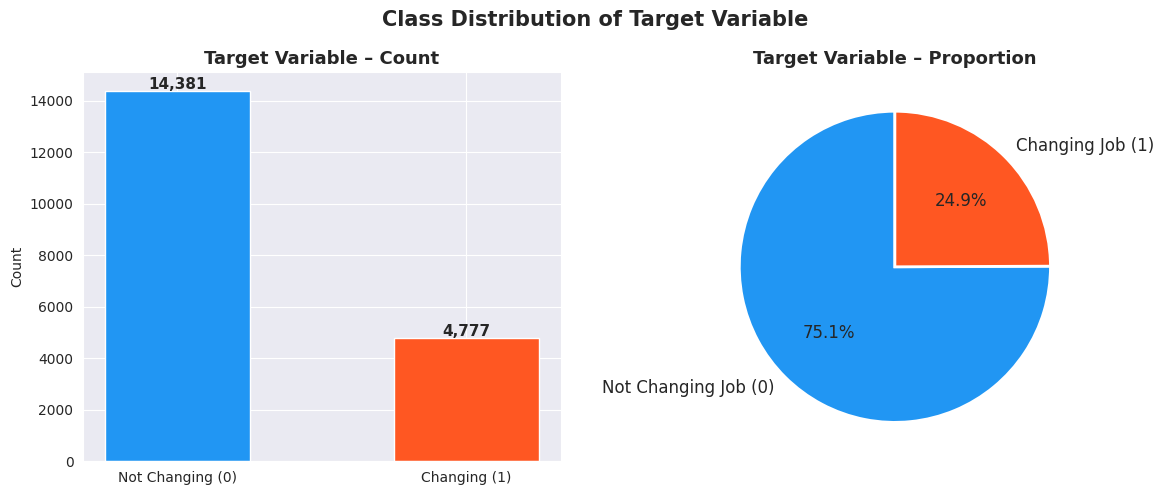

Observation: Dataset is imbalanced — ~75% not changing, ~25% changing.
We will handle this using SMOTE in the preprocessing step.


In [64]:
# ── Target Variable Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count bar
counts = df['target'].value_counts().sort_index()
bars = axes[0].bar(['Not Changing (0)', 'Changing (1)'], counts.values,
                   color=['#2196F3', '#FF5722'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Target Variable – Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values,
            labels=['Not Changing Job (0)', 'Changing Job (1)'],
            autopct='%1.1f%%',
            colors=['#2196F3', '#FF5722'],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 12})
axes[1].set_title('Target Variable – Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution of Target Variable', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation: Dataset is imbalanced — ~75% not changing, ~25% changing.')
print('We will handle this using SMOTE in the preprocessing step.')

### Step 3.2 | Summary Statistics – Numerical Features <a id='step32'></a>
---
[Table of Contents](#)

In [22]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in ['enrollee_id', 'target']]
print(f'Numerical Features: {numerical_cols}')
print()
df[numerical_cols].describe().T.round(2)

Numerical Features: ['city_development_index', 'training_hours']



,count,mean,std,min,25%,50%,75%,max
city_development_index,19158.0,0.83,0.12,0.45,0.74,0.9,0.92,0.95
training_hours,19158.0,65.37,60.06,1.00,23.00,47.0,88.00,336.00


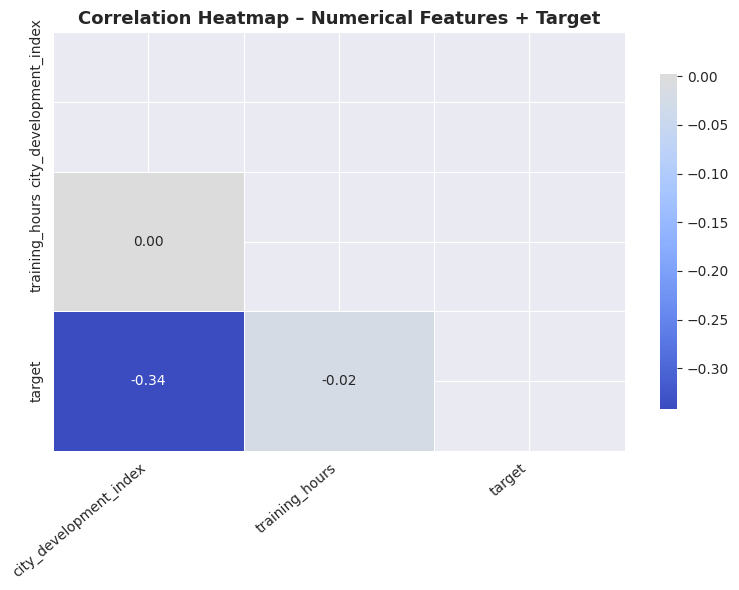

Observation: city_development_index has the strongest negative
correlation with target — lower CDI = higher chance of job change.


In [23]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
num_for_corr = numerical_cols + ['target']
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_for_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap – Numerical Features + Target',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print('Observation: city_development_index has the strongest negative')
print('correlation with target — lower CDI = higher chance of job change.')

### Step 3.3 | Summary Statistics – Categorical Features <a id='step33'></a>
---
[Table of Contents](#)

In [24]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical Features: {categorical_cols}')
print()
for col in categorical_cols:
    print(f'{chr(45)*50}')
    print(f'Column : {col}')
    print(f'Unique : {df[col].nunique()}  |  Missing: {df[col].isnull().sum()}')
    print(df[col].value_counts(dropna=False))
    print()

Categorical Features: ['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']

--------------------------------------------------
Column : city
Unique : 123  |  Missing: 0
city
city_103    4355
city_21     2702
city_16     1533
city_114    1336
city_160     845
            ... 
city_111       3
city_129       3
city_121       3
city_140       1
city_171       1
Name: count, Length: 123, dtype: int64

--------------------------------------------------
Column : gender
Unique : 3  |  Missing: 4508
gender
Male      13221
NaN        4508
Female     1238
Other       191
Name: count, dtype: int64

--------------------------------------------------
Column : relevent_experience
Unique : 2  |  Missing: 0
relevent_experience
Has relevent experience    13792
No relevent experience      5366
Name: count, dtype: int64

--------------------------------------------------
Column : enrolled_univ

## Step 4 | EDA – Exploratory Data Analysis <a id='step4'></a>
---
[Table of Contents](#)

We perform EDA to understand how features are distributed individually (univariate) and how they relate to the target variable (bivariate). These insights directly guide our preprocessing and feature engineering decisions.

### Step 4.1 | Univariate Analysis <a id='step41'></a>
---
[Table of Contents](#)

#### Step 4.1.1 | Numerical Variables <a id='step411'></a>

Histograms with KDE reveal the shape and spread of each numerical feature.

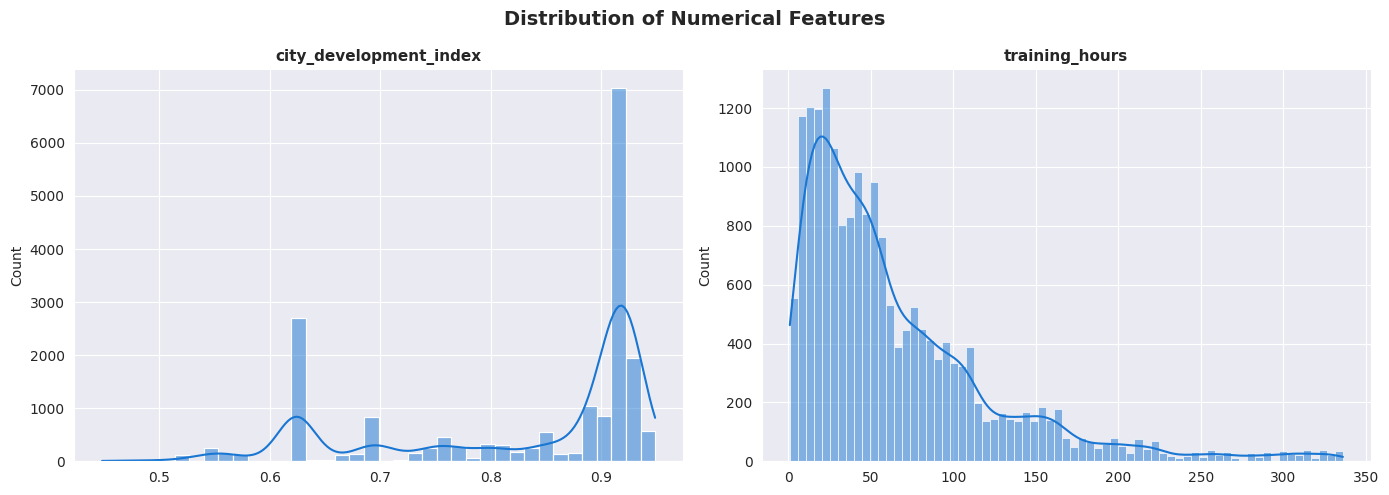

Observations:
- city_development_index : Bimodal distribution — two groups of cities.
- training_hours         : Right-skewed — most candidates train fewer hours.


In [25]:
# ── Histograms with KDE ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(14, 5))
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i],
                 color='#1976D2', edgecolor='white')
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')
plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observations:')
print('- city_development_index : Bimodal distribution — two groups of cities.')
print('- training_hours         : Right-skewed — most candidates train fewer hours.')

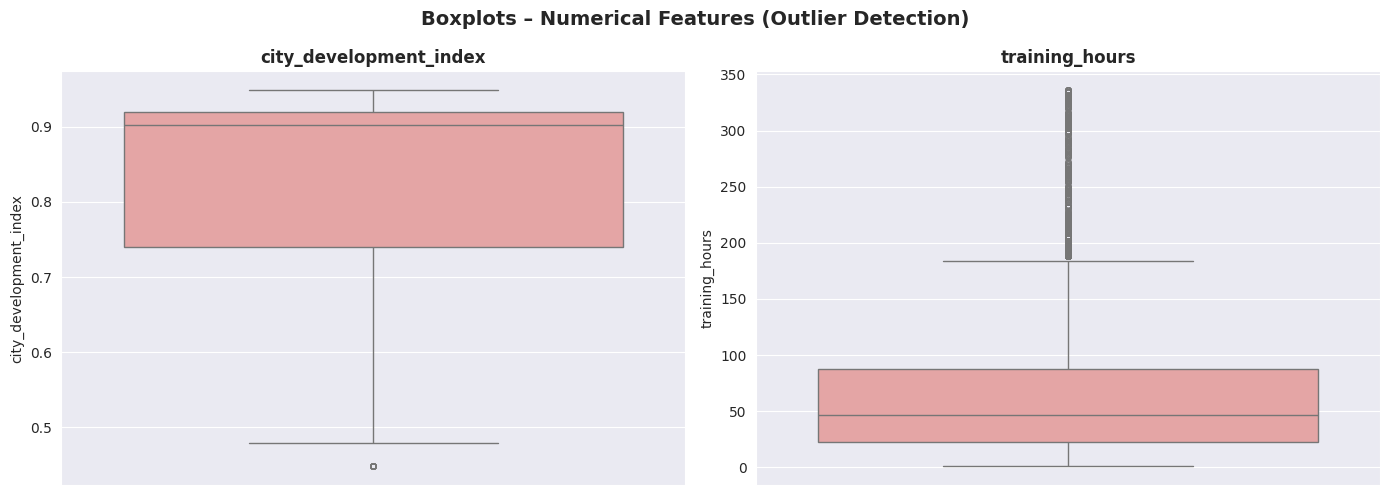

In [26]:
# ── Boxplots – Outlier Detection ──────────────────────────────────────────────
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(14, 5))
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color='#EF9A9A',
                flierprops=dict(marker='o', color='red', alpha=0.4, markersize=4))
    axes[i].set_title(f'{col}', fontweight='bold')
plt.suptitle('Boxplots – Numerical Features (Outlier Detection)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

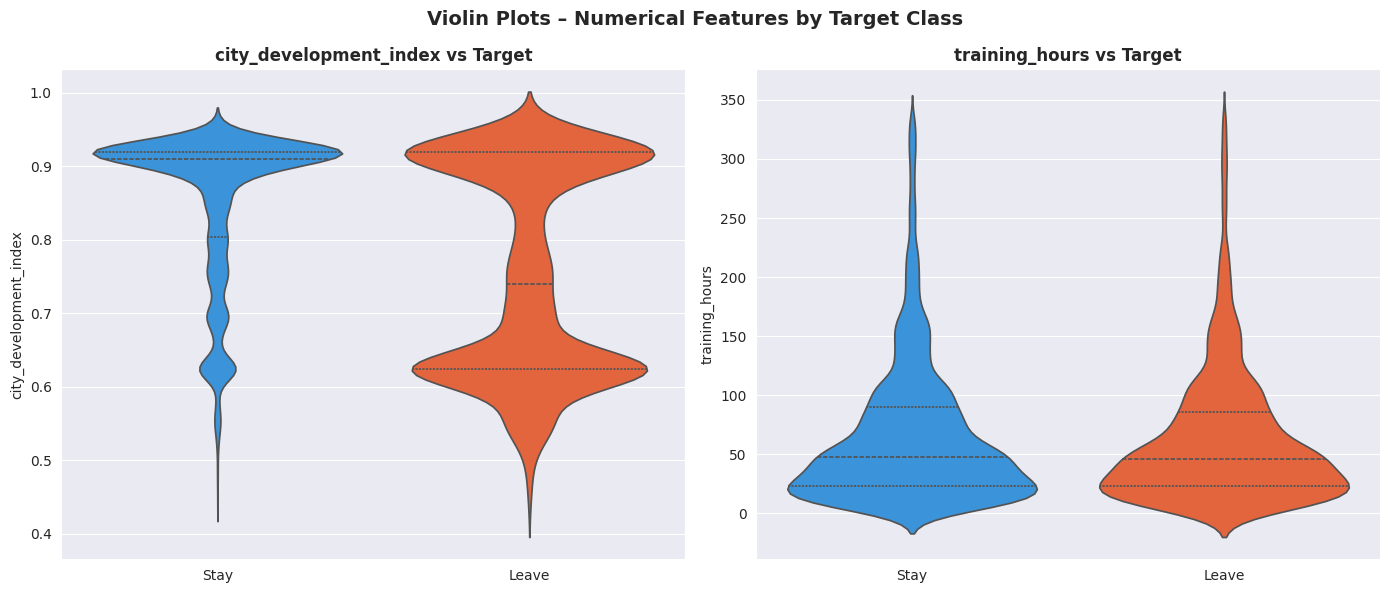

In [27]:
# ── Violin Plots – Distribution by Target ────────────────────────────────────
df_temp = df.copy()
df_temp['Job Status'] = df_temp['target'].map({0.0: 'Stay', 1.0: 'Leave'})

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(14, 6))
for i, col in enumerate(numerical_cols):
    sns.violinplot(data=df_temp, x='Job Status', y=col, ax=axes[i],
                   palette={'Stay': '#2196F3', 'Leave': '#FF5722'},
                   inner='quartile', order=['Stay', 'Leave'])
    axes[i].set_title(f'{col} vs Target', fontweight='bold')
    axes[i].set_xlabel('')
plt.suptitle('Violin Plots – Numerical Features by Target Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
del df_temp

#### Step 4.1.2 | Categorical Variables <a id='step412'></a>

Count plots reveal the frequency distribution of each categorical feature.

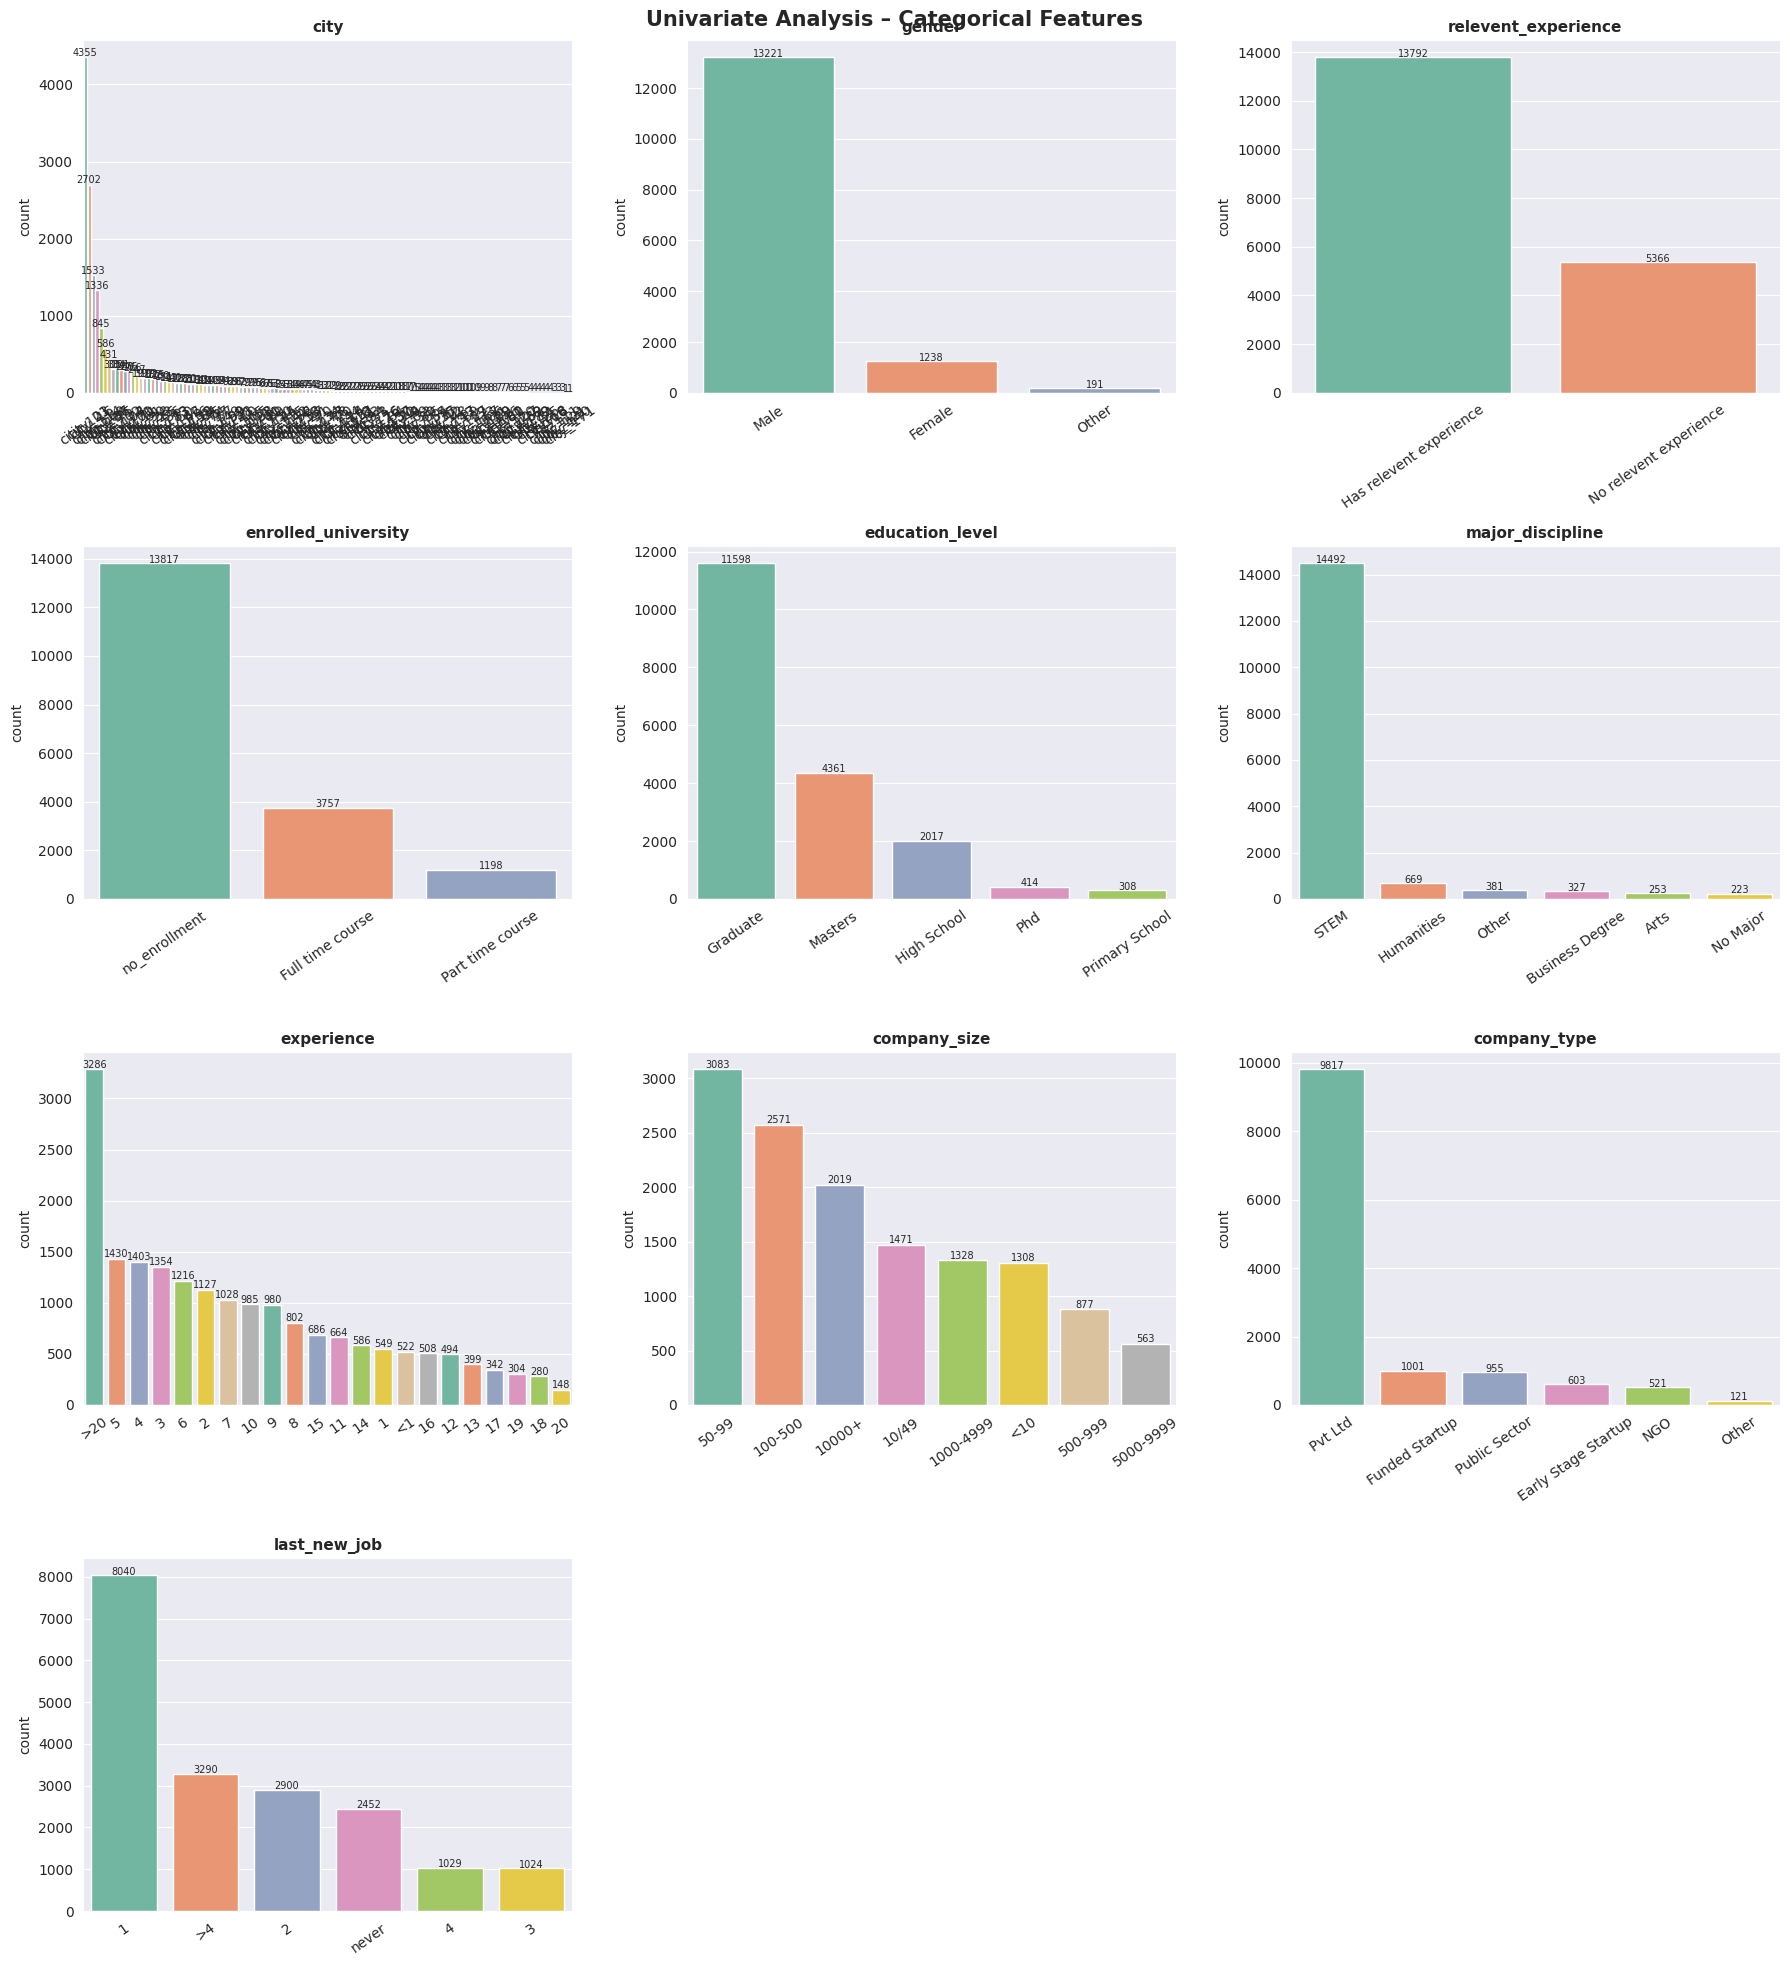

In [28]:
# ── Count Plots – All Categorical Features ───────────────────────────────────
n_cols_p = 3
n_rows_p = -(-len(categorical_cols) // n_cols_p)
fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(18, n_rows_p * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], order=order,
                  palette='Set2', edgecolor='white')
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    for p in axes[i].patches:
        axes[i].text(p.get_x() + p.get_width()/2, p.get_height() + 15,
                     f'{int(p.get_height())}', ha='center', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Analysis – Categorical Features',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

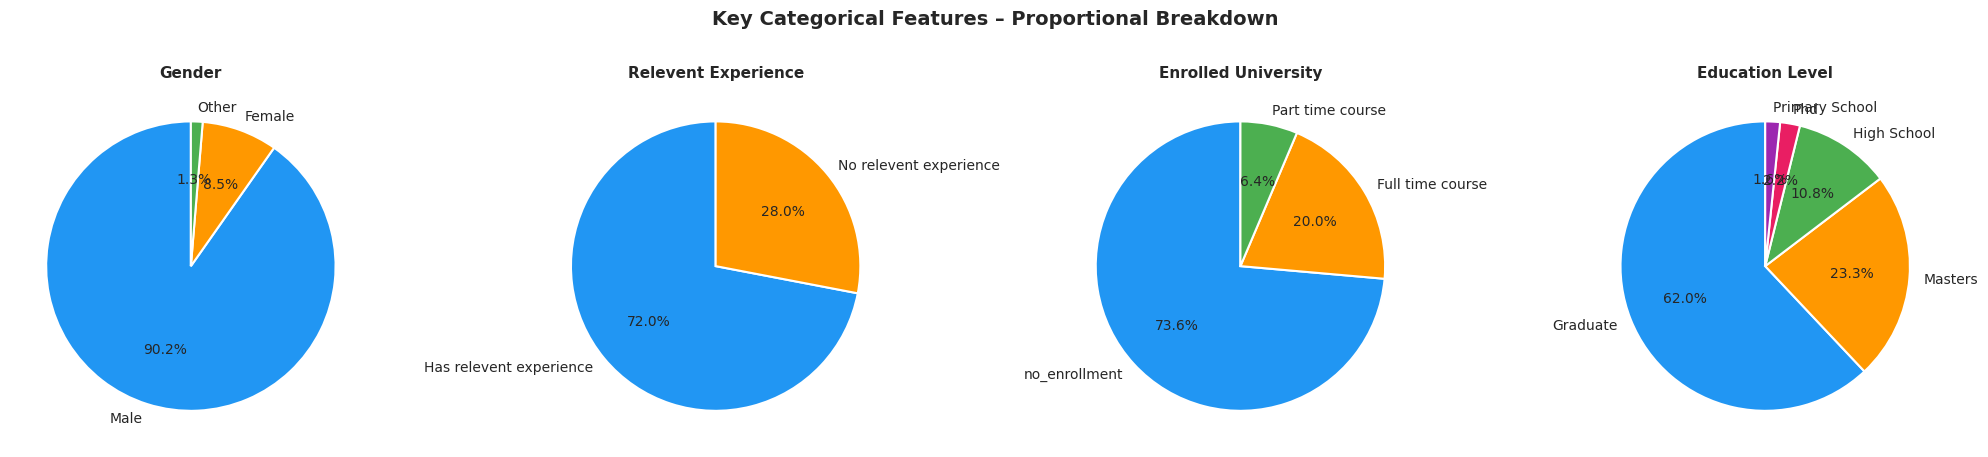

In [29]:
# ── Pie Charts – Key Categorical Features ────────────────────────────────────
key_cats = ['gender', 'relevent_experience', 'enrolled_university', 'education_level']
colors_pie = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0', '#00BCD4']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(key_cats):
    counts = df[col].value_counts()
    axes[i].pie(counts,
                labels=counts.index,
                autopct='%1.1f%%',
                colors=colors_pie[:len(counts)],
                startangle=90,
                wedgeprops=dict(edgecolor='white', linewidth=1.5))
    axes[i].set_title(col.replace('_', ' ').title(),
                      fontweight='bold', fontsize=11)

plt.suptitle('Key Categorical Features – Proportional Breakdown',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 4.2 | Bivariate Analysis <a id='step42'></a>
---
[Table of Contents](#)

#### Step 4.2.1 | Numerical Features vs Target <a id='step421'></a>

KDE plots split by target show how distributions differ between candidates who stay vs leave.

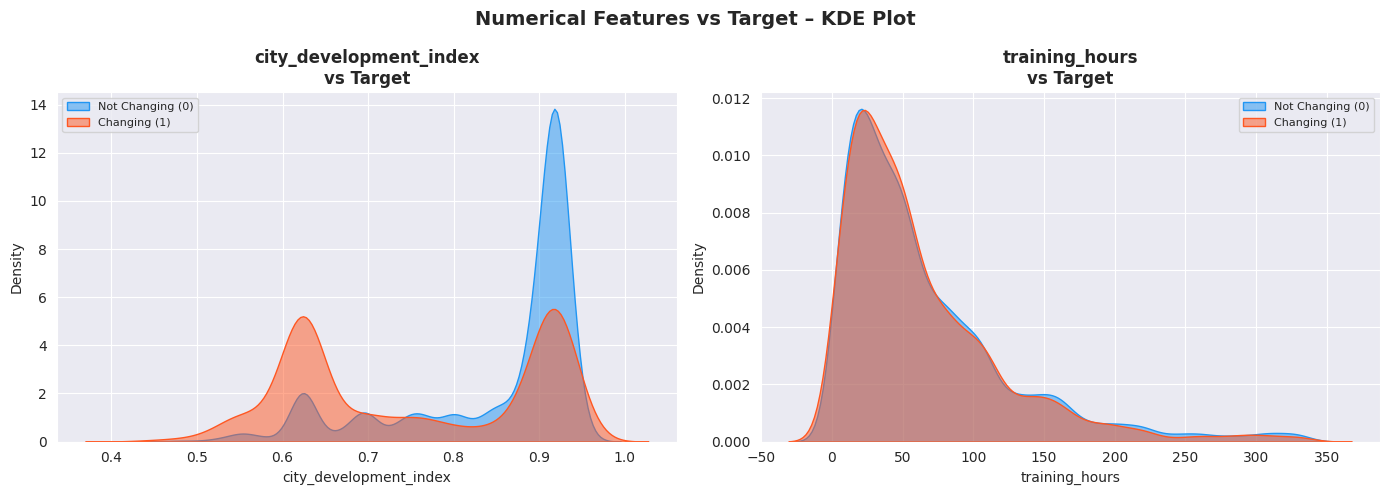

In [30]:
# ── KDE Plots – Numerical vs Target ──────────────────────────────────────────
df_temp = df.copy()
df_temp['target'] = df_temp['target'].astype(int)

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(14, 5))
for i, col in enumerate(numerical_cols):
    for val, color, label in [(0, '#2196F3', 'Not Changing (0)'),
                               (1, '#FF5722', 'Changing (1)')]:
        sns.kdeplot(df_temp[df_temp['target'] == val][col].dropna(),
                    ax=axes[i], fill=True, color=color, alpha=0.5, label=label)
    axes[i].set_title(f'{col}\nvs Target', fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('Numerical Features vs Target – KDE Plot',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
del df_temp

#### Step 4.2.2 | Categorical Features vs Target <a id='step422'></a>

Stacked percentage bars show what proportion within each category is looking for a job change.

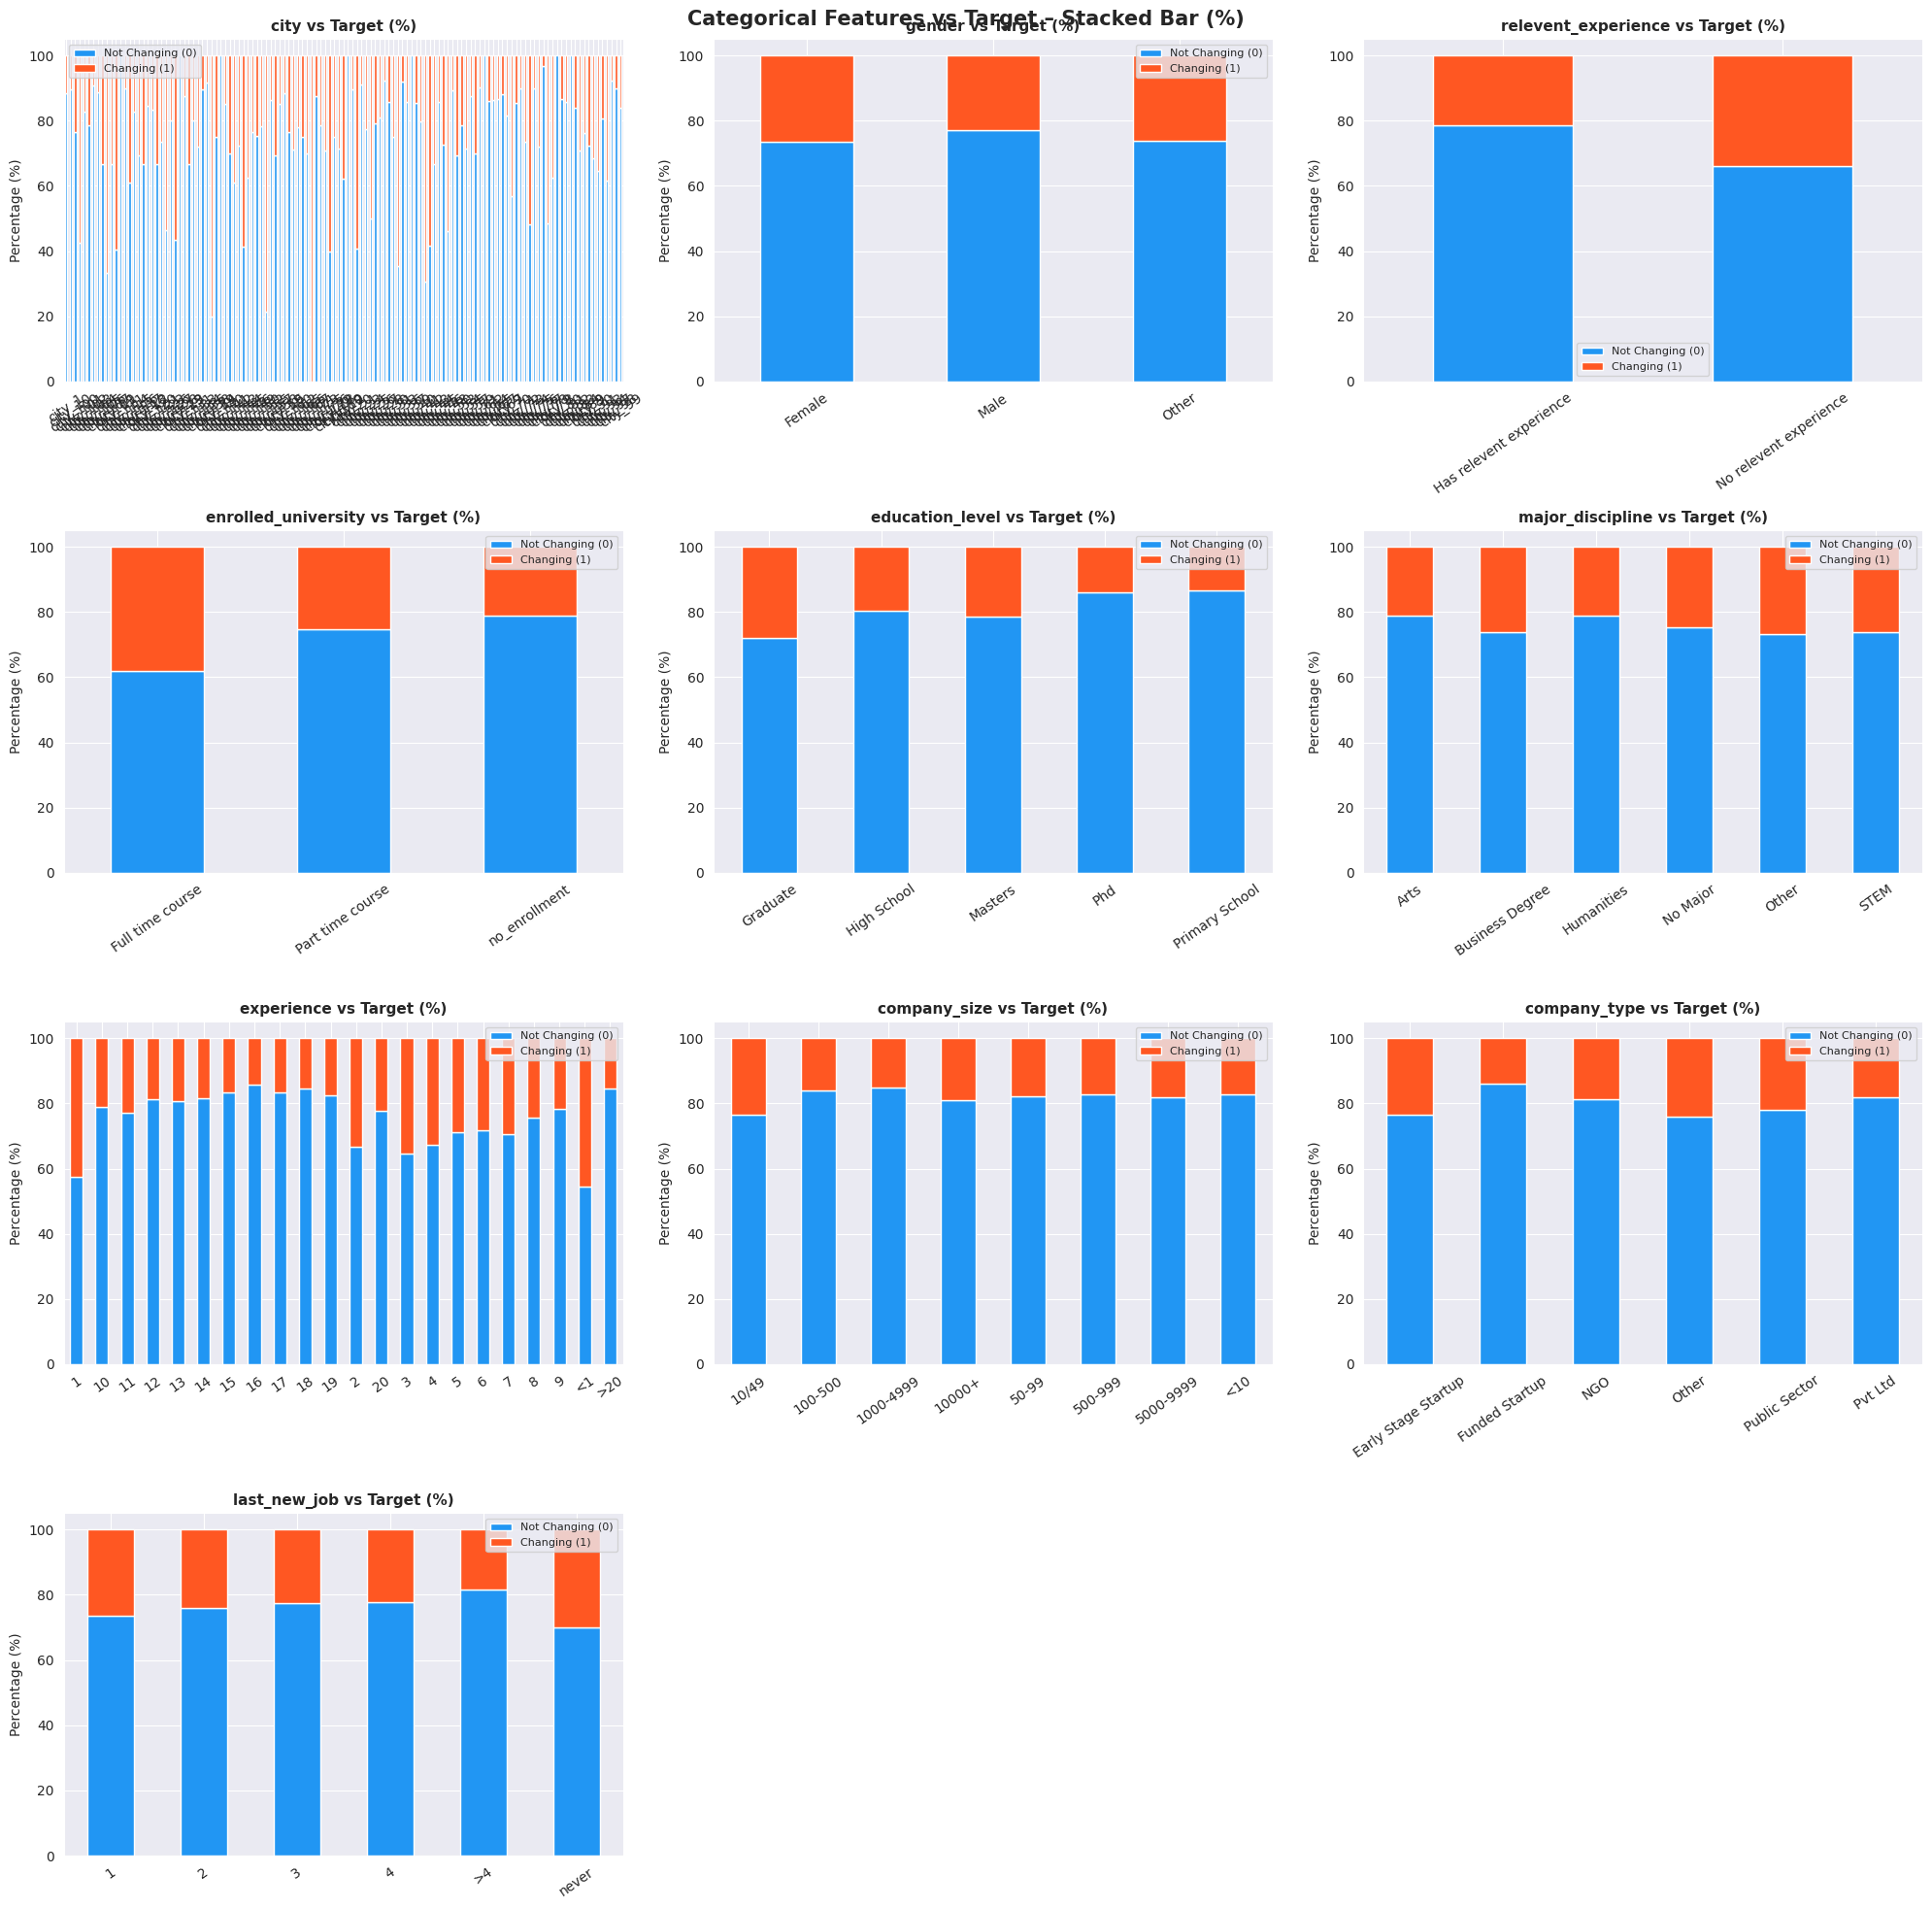

Observations:
- Candidates without relevant experience switch more often.
- Full-time university students show higher job-change intent.
- Startup employees are more open to switching.
- Candidates who last changed job 4+ years ago are more likely to switch.


In [31]:
# ── Stacked Bar Chart – Categorical vs Target ────────────────────────────────
n_cols_p = 3
n_rows_p = -(-len(categorical_cols) // n_cols_p)
fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(20, n_rows_p * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.columns = ['Not Changing (0)', 'Changing (1)']
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#2196F3', '#FF5722'], edgecolor='white')
    axes[i].set_title(f'{col} vs Target (%)', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Target – Stacked Bar (%)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observations:')
print('- Candidates without relevant experience switch more often.')
print('- Full-time university students show higher job-change intent.')
print('- Startup employees are more open to switching.')
print('- Candidates who last changed job 4+ years ago are more likely to switch.')

## Step 5 | Data Preprocessing <a id='step5'></a>
---
[Table of Contents](#)

We clean and transform the raw data so it is suitable for machine learning.

**Pipeline:** Drop Irrelevant → Fill Missing → Cap Outliers → Encode → Scale → SMOTE

### Step 5.1 | Irrelevant Features Removal <a id='step51'></a>
---
[Table of Contents](#)

All features appear relevant based on EDA. We only drop `enrollee_id` (unique ID, no predictive value) and `city` (already captured by `city_development_index`).

In [32]:
df.drop(columns=['enrollee_id', 'city'], inplace=True)
df_test.drop(columns=['enrollee_id', 'city'], inplace=True)

print('Columns after removal:')
print(df.columns.tolist())
print(f'Shape: {df.shape}')

Columns after removal:
['city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'target']
Shape: (19158, 12)


### Step 5.2 | Missing Value Treatment <a id='step52'></a>
---
[Table of Contents](#)

In [33]:
# Check total missing
print('Total missing values:', df.isnull().sum().sum())
df.isnull().sum()

Total missing values: 20733


,0
city_development_index,0
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938
company_type,6140
last_new_job,423


In [34]:
# Fill with mode (most frequent value) for categorical columns
cols_to_fill = ['gender', 'major_discipline', 'company_size',
                'company_type', 'last_new_job', 'enrolled_university']

for col in cols_to_fill:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    df_test[col].fillna(mode_val, inplace=True)

print(f'Total missing after treatment: {df.isnull().sum().sum()}')
print('All missing values handled successfully!')

Total missing after treatment: 525
All missing values handled successfully!


### Step 5.3 | Outlier Treatment <a id='step53'></a>
---
[Table of Contents](#)

I am going to check for outliers using the **IQR method** for the continuous features:

In [35]:
continuous_features = ['city_development_index', 'training_hours']
continuous_features

['city_development_index', 'training_hours']

In [36]:
# ── IQR Outlier Detection ─────────────────────────────────────────────────────
for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}:')
    print(f'  Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f}')
    print(f'  Lower={lower:.2f} | Upper={upper:.2f} | Outliers={outliers}')
    print()

city_development_index:
  Q1=0.74 | Q3=0.92 | IQR=0.18
  Lower=0.47 | Upper=1.19 | Outliers=17

training_hours:
  Q1=23.00 | Q3=88.00 | IQR=65.00
  Lower=-74.50 | Upper=185.50 | Outliers=984



Outliers capped using IQR Winsorization.


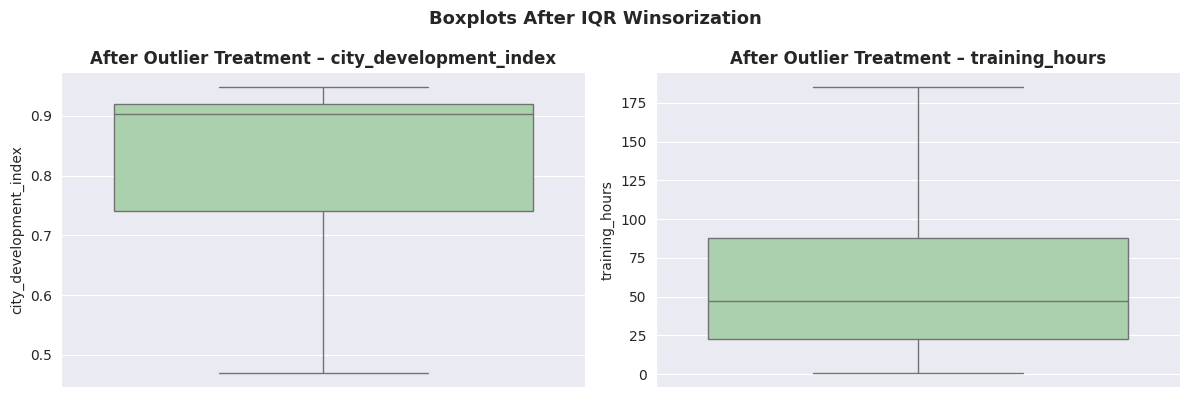

In [37]:
# ── Cap Outliers using Winsorization ─────────────────────────────────────────
for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)
    df_test[col] = df_test[col].clip(lower=lower, upper=upper)

print('Outliers capped using IQR Winsorization.')

# Boxplots after treatment
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(continuous_features):
    sns.boxplot(y=df[col], ax=axes[i], color='#A5D6A7')
    axes[i].set_title(f'After Outlier Treatment – {col}', fontweight='bold')
plt.suptitle('Boxplots After IQR Winsorization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 5.4 | Categorical Feature Encoding <a id='step54'></a>
---
[Table of Contents](#)

We first clean `experience` and `last_new_job` which have mixed text/number values like `>20`, `<1`, `>4`, `never`. Then we apply **Label Encoding** to all remaining categorical columns.

In [38]:
# ── Clean 'experience' ───────────────────────────────────────────────────────
df['experience']      = df['experience'].replace({'>20': '21', '<1': '0'})
df_test['experience'] = df_test['experience'].replace({'>20': '21', '<1': '0'})
df['experience']      = pd.to_numeric(df['experience'], errors='coerce')
df_test['experience'] = pd.to_numeric(df_test['experience'], errors='coerce')
df['experience'].fillna(df['experience'].median(), inplace=True)
df_test['experience'].fillna(df['experience'].median(), inplace=True)

# ── Clean 'last_new_job' ──────────────────────────────────────────────────────
df['last_new_job']      = df['last_new_job'].replace({'never': '0', '>4': '5'})
df_test['last_new_job'] = df_test['last_new_job'].replace({'never': '0', '>4': '5'})
df['last_new_job']      = pd.to_numeric(df['last_new_job'], errors='coerce')
df_test['last_new_job'] = pd.to_numeric(df_test['last_new_job'], errors='coerce')
df['last_new_job'].fillna(df['last_new_job'].median(), inplace=True)
df_test['last_new_job'].fillna(df['last_new_job'].median(), inplace=True)

print('experience and last_new_job cleaned.')
print(df[['experience', 'last_new_job']].dtypes)

experience and last_new_job cleaned.
experience      float64
last_new_job      int64
dtype: object


In [39]:
# ── Label Encoding ───────────────────────────────────────────────────────────
le = LabelEncoder()
cat_encode_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Columns to encode: {cat_encode_cols}')

for col in cat_encode_cols:
    df[col]      = le.fit_transform(df[col].astype(str))
    df_test[col] = le.fit_transform(df_test[col].astype(str))

print('Label Encoding complete.')
print(f'Final shape: {df.shape}')
df.head()

Columns to encode: ['gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_size', 'company_type']
Label Encoding complete.
Final shape: (19158, 12)


,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,0.920,1,0,2,0,5,21.0,4,5,1,36.0,1.0
1,0.776,1,1,2,0,5,15.0,4,5,5,47.0,0.0
2,0.624,1,1,0,0,5,5.0,4,5,0,83.0,0.0
3,0.789,1,1,2,0,1,0.0,4,5,0,52.0,1.0
4,0.767,1,0,2,2,5,21.0,4,1,4,8.0,0.0


### Step 5.5 | Feature Scaling <a id='step55'></a>
---
[Table of Contents](#)

We apply **StandardScaler** to normalize numerical features so no single feature dominates due to scale differences.

In [40]:
# ── Separate Features and Target ─────────────────────────────────────────────
X = df.drop(columns=['target'])
y = df['target']
X_test_final = df_test.copy()

# ── Train-Test Split (80-20, stratified) ─────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training Set   : {X_train.shape}')
print(f'Validation Set : {X_val.shape}')

# ── StandardScaler ───────────────────────────────────────────────────────────
scale_cols = ['city_development_index', 'training_hours', 'experience', 'last_new_job']
scaler = StandardScaler()
X_train[scale_cols]      = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols]         = scaler.transform(X_val[scale_cols])
X_test_final[scale_cols]  = scaler.transform(X_test_final[scale_cols])

print('StandardScaler applied successfully.')

Training Set   : (15326, 11)
Validation Set : (3832, 11)
StandardScaler applied successfully.


### Step 5.6 | Handling Class Imbalance – SMOTE <a id='step56'></a>
---
[Table of Contents](#)

**SMOTE** (Synthetic Minority Oversampling Technique) creates synthetic samples of the minority class to balance the training data. Applied ONLY on training set to prevent data leakage.

In [41]:
print('Before SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_sm).value_counts())
print(f'\nNew training size: {X_train_sm.shape}')

Before SMOTE:
target
0.0    11504
1.0     3822
Name: count, dtype: int64

After SMOTE:
target
0.0    11504
1.0    11504
Name: count, dtype: int64

New training size: (23008, 11)


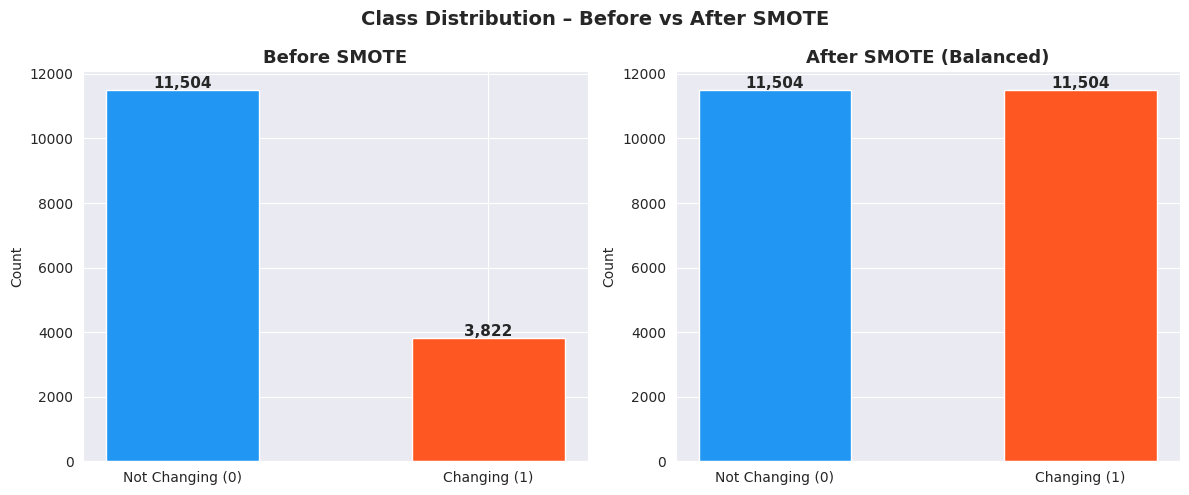

In [42]:
# ── Visualize SMOTE Effect ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

before = y_train.value_counts().sort_index()
after  = pd.Series(y_train_sm).value_counts().sort_index()

for ax, data, title in [(axes[0], before, 'Before SMOTE'),
                         (axes[1], after,  'After SMOTE (Balanced)')]:
    bars = ax.bar(['Not Changing (0)', 'Changing (1)'], data.values,
                  color=['#2196F3', '#FF5722'], edgecolor='white', width=0.5)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('Count')

plt.suptitle('Class Distribution – Before vs After SMOTE',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Helper Function | Model Evaluation

A reusable function that prints metrics and plots Confusion Matrix + ROC Curve for any trained model.

In [43]:
model_results = {}

def evaluate_model(model_name, model, X_val, y_val):
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    acc     = accuracy_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)

    model_results[model_name] = {
        'Accuracy': round(acc * 100, 2),
        'ROC-AUC' : round(roc_auc, 4),
        'model'   : model,
        'y_pred'  : y_pred,
        'y_proba' : y_proba
    }

    print(f'{'='*52}')
    print(f'  Model    : {model_name}')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'  ROC-AUC  : {roc_auc:.4f}')
    print(f'{'='*52}')
    print(classification_report(y_val, y_pred,
          target_names=['Not Changing (0)', 'Changing (1)']))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels=['Not Changing', 'Changing'],
        cmap='Blues', ax=axes[0]
    )
    axes[0].set_title(f'{model_name} – Confusion Matrix', fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2.5,
                 label=f'ROC Curve (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{model_name} – ROC Curve', fontweight='bold')
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

print('evaluate_model() defined successfully.')

evaluate_model() defined successfully.


## Step 6 | Logistic Regression Model <a id='step6'></a>
---
[Table of Contents](#)

A foundational linear classification algorithm. It models the probability of the target as a linear combination of features. Serves as our **interpretable baseline model**.

### Step 6.1 | LR Base Model <a id='step61'></a>
[Table of Contents](#)

In [44]:
lr_base = LogisticRegression(random_state=42, max_iter=1000)
lr_base.fit(X_train_sm, y_train_sm)
y_pred_base = lr_base.predict(X_val)
print(f'LR Base Accuracy: {accuracy_score(y_val, y_pred_base)*100:.2f}%')

LR Base Accuracy: 70.46%


### Step 6.2 | LR Hyperparameter Tuning <a id='step62'></a>
[Table of Contents](#)

Using **GridSearchCV** with 5-fold cross-validation, optimizing for ROC-AUC score.

In [45]:
lr_params = {
    'C'       : [0.01, 0.1, 1, 10],
    'solver'  : ['lbfgs', 'liblinear'],
    'penalty' : ['l2']
}
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    lr_params, cv=5, scoring='roc_auc', n_jobs=-1
)
lr_grid.fit(X_train_sm, y_train_sm)
print(f'Best Parameters : {lr_grid.best_params_}')
print(f'Best CV ROC-AUC : {lr_grid.best_score_:.4f}')
lr_best = lr_grid.best_estimator_

Best Parameters : {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC : 0.7340


### Step 6.3 | LR Model Evaluation <a id='step63'></a>
[Table of Contents](#)

  Model    : Logistic Regression
  Accuracy : 70.43%
  ROC-AUC  : 0.7428
                  precision    recall  f1-score   support

Not Changing (0)       0.87      0.72      0.78      2877
    Changing (1)       0.44      0.67      0.53       955

        accuracy                           0.70      3832
       macro avg       0.65      0.69      0.66      3832
    weighted avg       0.76      0.70      0.72      3832



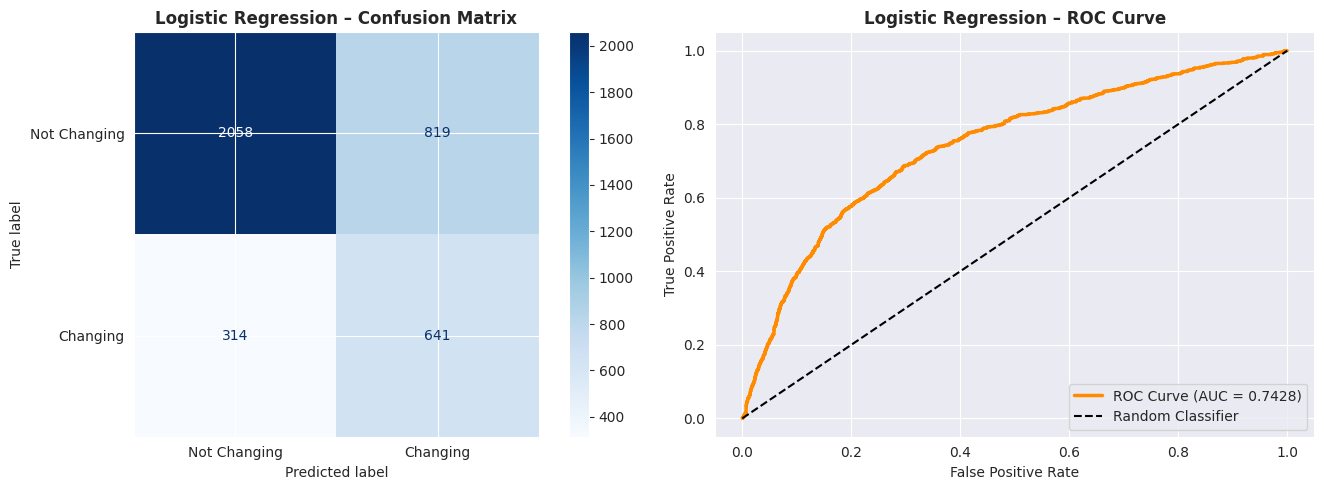

In [46]:
evaluate_model('Logistic Regression', lr_best, X_val, y_val)

## Step 7 | Random Forest Model <a id='step7'></a>
---
[Table of Contents](#)

An ensemble of decision trees trained on random subsets of data and features. Handles non-linearity well, robust to overfitting, and provides built-in feature importance.

### Step 7.1 | RF Base Model <a id='step71'></a>
[Table of Contents](#)

In [47]:
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_base.fit(X_train_sm, y_train_sm)
y_pred_base = rf_base.predict(X_val)
print(f'RF Base Accuracy: {accuracy_score(y_val, y_pred_base)*100:.2f}%')

RF Base Accuracy: 76.38%


### Step 7.2 | RF Hyperparameter Tuning <a id='step72'></a>
[Table of Contents](#)

Using **GridSearchCV** with 5-fold cross-validation, optimizing for ROC-AUC score.

In [48]:
rf_params = {
    'n_estimators'      : [100, 200],
    'max_depth'         : [5, 10, None],
    'min_samples_split' : [2, 5],
    'max_features'      : ['sqrt', 'log2']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, cv=5, scoring='roc_auc', n_jobs=-1
)
rf_grid.fit(X_train_sm, y_train_sm)
print(f'Best Parameters : {rf_grid.best_params_}')
print(f'Best CV ROC-AUC : {rf_grid.best_score_:.4f}')
rf_best = rf_grid.best_estimator_

Best Parameters : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC : 0.9150


### Step 7.3 | RF Model Evaluation <a id='step73'></a>
[Table of Contents](#)

  Model    : Random Forest
  Accuracy : 76.54%
  ROC-AUC  : 0.7714
                  precision    recall  f1-score   support

Not Changing (0)       0.85      0.83      0.84      2877
    Changing (1)       0.53      0.56      0.54       955

        accuracy                           0.77      3832
       macro avg       0.69      0.70      0.69      3832
    weighted avg       0.77      0.77      0.77      3832



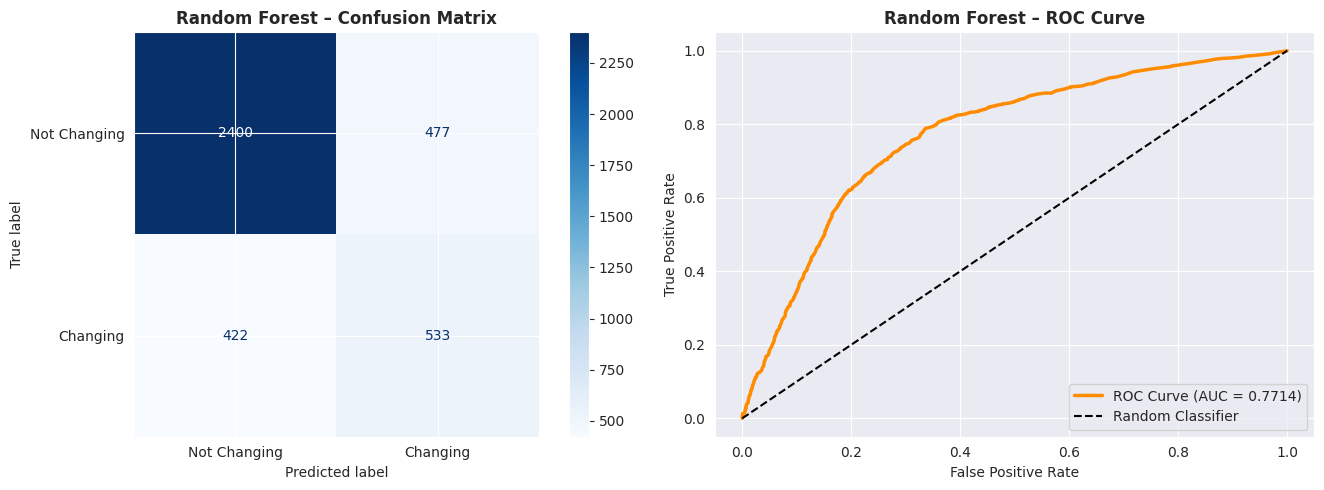

In [49]:
evaluate_model('Random Forest', rf_best, X_val, y_val)

## Step 8 | XGBoost Model <a id='step8'></a>
---
[Table of Contents](#)

Extreme Gradient Boosting builds trees sequentially, each correcting errors of the previous. Includes built-in L1/L2 regularization and is one of the top-performing algorithms for tabular data.

### Step 8.1 | XGB Base Model <a id='step81'></a>
[Table of Contents](#)

In [50]:
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss',
                          use_label_encoder=False)
xgb_base.fit(X_train_sm, y_train_sm)
y_pred_base = xgb_base.predict(X_val)
print(f'XGB Base Accuracy: {accuracy_score(y_val, y_pred_base)*100:.2f}%')

XGB Base Accuracy: 77.14%


### Step 8.2 | XGB Hyperparameter Tuning <a id='step82'></a>
[Table of Contents](#)

Using **GridSearchCV** with 5-fold cross-validation, optimizing for ROC-AUC score.

In [51]:
xgb_params = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.05, 0.1, 0.2],
    'subsample'     : [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss',
                  use_label_encoder=False),
    xgb_params, cv=5, scoring='roc_auc', n_jobs=-1
)
xgb_grid.fit(X_train_sm, y_train_sm)
print(f'Best Parameters : {xgb_grid.best_params_}')
print(f'Best CV ROC-AUC : {xgb_grid.best_score_:.4f}')
xgb_best = xgb_grid.best_estimator_

Best Parameters : {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best CV ROC-AUC : 0.9110


### Step 8.3 | XGB Model Evaluation <a id='step83'></a>
[Table of Contents](#)

  Model    : XGBoost
  Accuracy : 77.32%
  ROC-AUC  : 0.7799
                  precision    recall  f1-score   support

Not Changing (0)       0.85      0.85      0.85      2877
    Changing (1)       0.55      0.54      0.54       955

        accuracy                           0.77      3832
       macro avg       0.70      0.70      0.70      3832
    weighted avg       0.77      0.77      0.77      3832



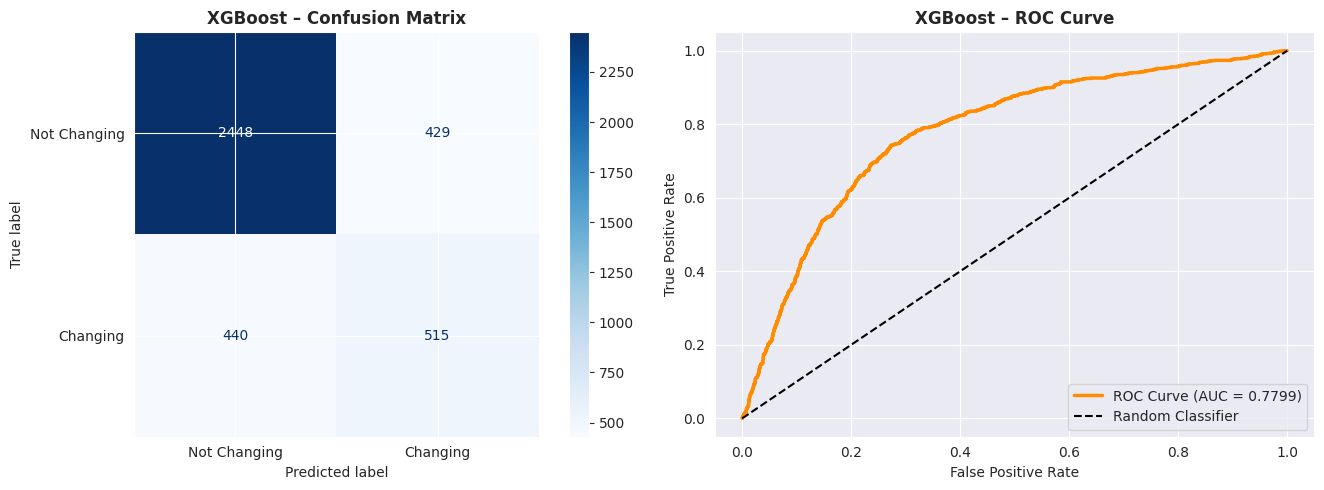

In [52]:
evaluate_model('XGBoost', xgb_best, X_val, y_val)

## Step 9 | LightGBM Model <a id='step9'></a>
---
[Table of Contents](#)

Microsoft's gradient boosting with leaf-wise tree growth and histogram-based binning. Significantly faster than XGBoost on large datasets while achieving competitive or better accuracy.

### Step 9.1 | LGBM Base Model <a id='step91'></a>
[Table of Contents](#)

In [53]:
lgbm_base = LGBMClassifier(random_state=42, verbosity=-1)
lgbm_base.fit(X_train_sm, y_train_sm)
y_pred_base = lgbm_base.predict(X_val)
print(f'LGBM Base Accuracy: {accuracy_score(y_val, y_pred_base)*100:.2f}%')

LGBM Base Accuracy: 78.13%


### Step 9.2 | LGBM Hyperparameter Tuning <a id='step92'></a>
[Table of Contents](#)

Using **GridSearchCV** with 5-fold cross-validation, optimizing for ROC-AUC score.

In [54]:
lgbm_params = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.05, 0.1, 0.2],
    'num_leaves'    : [31, 63]
}
lgbm_grid = GridSearchCV(
    LGBMClassifier(random_state=42, verbosity=-1),
    lgbm_params, cv=5, scoring='roc_auc', n_jobs=-1
)
lgbm_grid.fit(X_train_sm, y_train_sm)
print(f'Best Parameters : {lgbm_grid.best_params_}')
print(f'Best CV ROC-AUC : {lgbm_grid.best_score_:.4f}')
lgbm_best = lgbm_grid.best_estimator_

Best Parameters : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'num_leaves': 63}
Best CV ROC-AUC : 0.9194


### Step 9.3 | LGBM Model Evaluation <a id='step93'></a>
[Table of Contents](#)

  Model    : LightGBM
  Accuracy : 77.56%
  ROC-AUC  : 0.7933
                  precision    recall  f1-score   support

Not Changing (0)       0.85      0.85      0.85      2877
    Changing (1)       0.55      0.54      0.55       955

        accuracy                           0.78      3832
       macro avg       0.70      0.70      0.70      3832
    weighted avg       0.77      0.78      0.77      3832



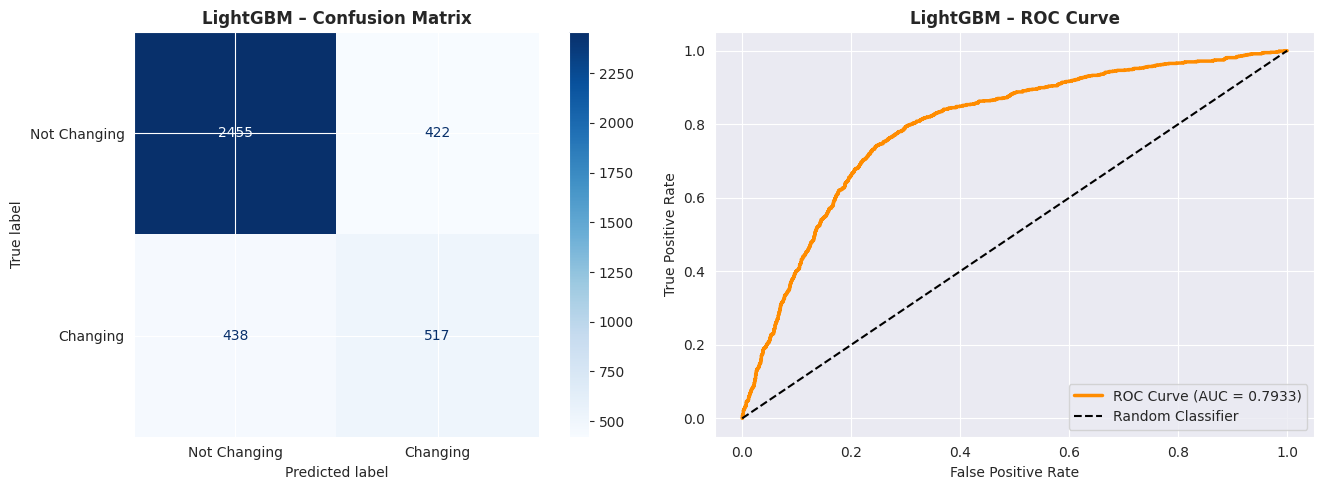

In [55]:
evaluate_model('LightGBM', lgbm_best, X_val, y_val)

## Step 10 | Model Comparison <a id='step10'></a>
---
[Table of Contents](#)

We compare all four models using Accuracy and ROC-AUC. Since the dataset is imbalanced, **ROC-AUC is the primary metric**.

In [56]:
comparison_df = pd.DataFrame({
    'Model'    : list(model_results.keys()),
    'Accuracy' : [v['Accuracy'] for v in model_results.values()],
    'ROC-AUC'  : [v['ROC-AUC']  for v in model_results.values()]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print('Model Comparison:')
print('-' * 45)
print(comparison_df.to_string(index=False))
print()
print(f"Best Model (by ROC-AUC): {comparison_df.iloc[0]['Model']}")

Model Comparison:
---------------------------------------------
              Model  Accuracy  ROC-AUC
           LightGBM     77.56   0.7933
            XGBoost     77.32   0.7799
      Random Forest     76.54   0.7714
Logistic Regression     70.43   0.7428

Best Model (by ROC-AUC): LightGBM


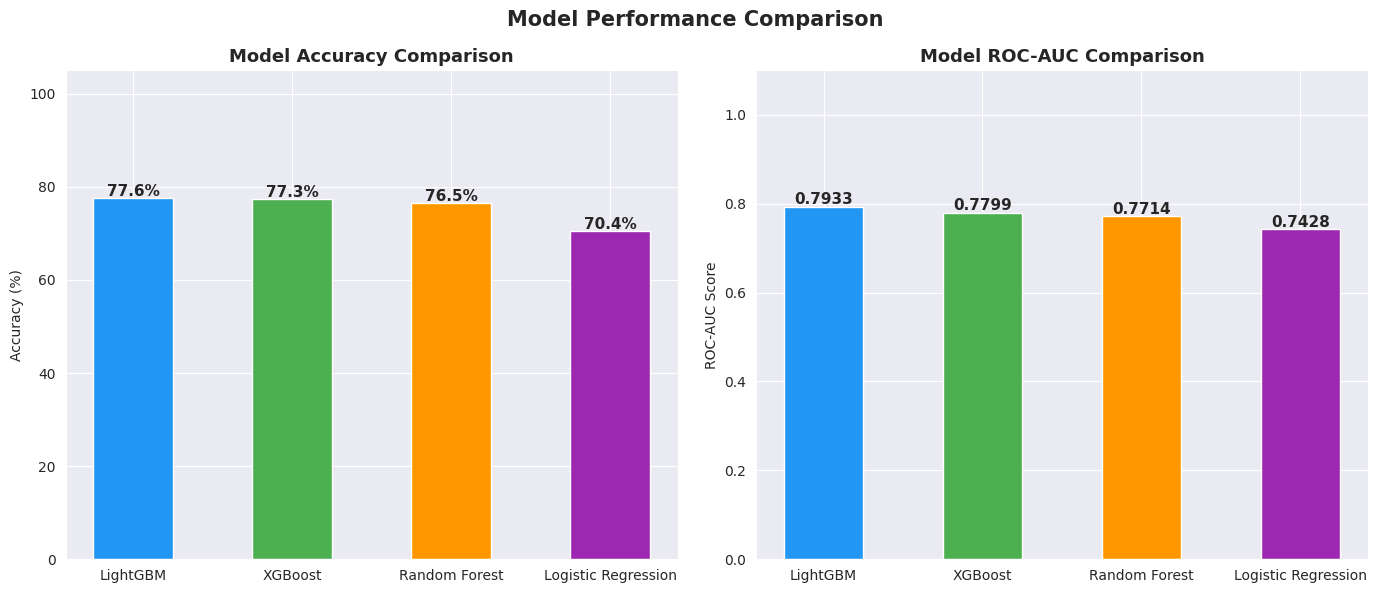

In [57]:
# ── Bar Charts – Accuracy & ROC-AUC ──────────────────────────────────────────
colors_m = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars1 = axes[0].bar(comparison_df['Model'], comparison_df['Accuracy'],
                    color=colors_m, edgecolor='white', width=0.5)
for bar, val in zip(bars1, comparison_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Model Accuracy Comparison', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 105)

bars2 = axes[1].bar(comparison_df['Model'], comparison_df['ROC-AUC'],
                    color=colors_m, edgecolor='white', width=0.5)
for bar, val in zip(bars2, comparison_df['ROC-AUC']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Model ROC-AUC Comparison', fontweight='bold', fontsize=13)
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0, 1.1)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

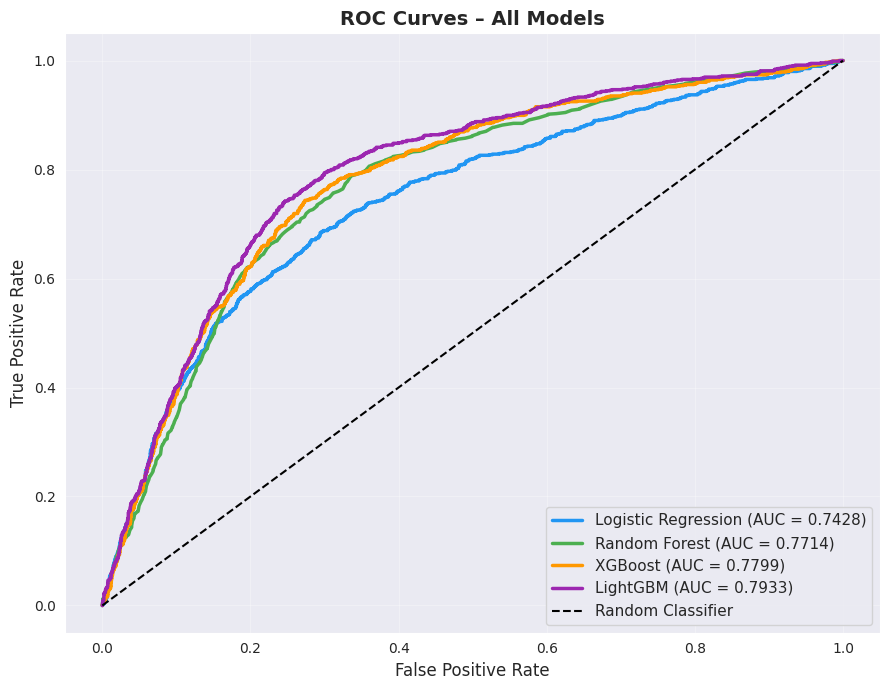

In [58]:
# ── Combined ROC Curves ───────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
colors_roc = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for (name, result), color in zip(model_results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_val, result['y_proba'])
    plt.plot(fpr, tpr, lw=2.5, color=color,
             label=f"{name} (AUC = {result['ROC-AUC']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves – All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 11 | Feature Importance <a id='step11'></a>
---
[Table of Contents](#)

We extract feature importances from the best model to understand which features drive the prediction most strongly.

In [59]:
best_model_name = comparison_df.iloc[0]['Model']
best_model_obj  = model_results[best_model_name]['model']
print(f'Best Model: {best_model_name}')

if hasattr(best_model_obj, 'feature_importances_'):
    feat_imp = pd.Series(best_model_obj.feature_importances_, index=X.columns)
else:
    feat_imp = pd.Series(np.abs(best_model_obj.coef_[0]), index=X.columns)

feat_imp = feat_imp.sort_values(ascending=False)
print(feat_imp)

Best Model: LightGBM
training_hours            2854
city_development_index    2532
experience                2422
last_new_job               995
company_size               901
education_level            620
enrolled_university        397
company_type               318
major_discipline           277
relevent_experience        264
gender                      83
dtype: int32


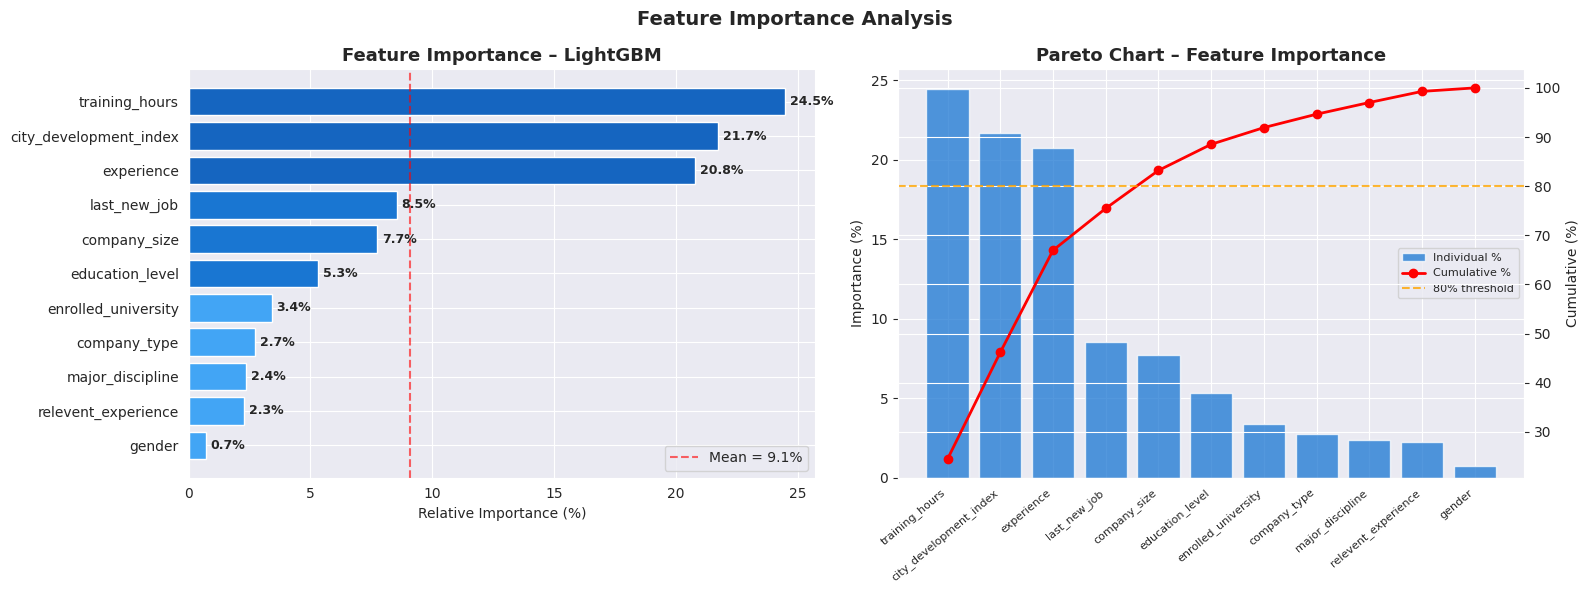

In [60]:
# ── Feature Importance Bar Chart ─────────────────────────────────────────────
feat_imp_pct = feat_imp / feat_imp.sum() * 100
colors_feat  = ['#1565C0' if i < 3 else '#1976D2' if i < 6 else '#42A5F5'
                for i in range(len(feat_imp))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar
axes[0].barh(feat_imp_pct.index[::-1], feat_imp_pct.values[::-1],
             color=colors_feat[::-1], edgecolor='white')
for i, val in enumerate(feat_imp_pct.values[::-1]):
    axes[0].text(val + 0.2, i, f'{val:.1f}%', va='center',
                 fontweight='bold', fontsize=9)
axes[0].set_title(f'Feature Importance – {best_model_name}',
                  fontweight='bold', fontsize=13)
axes[0].set_xlabel('Relative Importance (%)')
axes[0].axvline(feat_imp_pct.mean(), color='red', ls='--',
                alpha=0.6, label=f'Mean = {feat_imp_pct.mean():.1f}%')
axes[0].legend()

# Pareto chart
cumulative = feat_imp_pct.cumsum()
axes[1].bar(range(len(feat_imp)), feat_imp_pct.values,
            color='#1976D2', alpha=0.75, label='Individual %')
ax2 = axes[1].twinx()
ax2.plot(range(len(feat_imp)), cumulative.values, 'ro-', lw=2, label='Cumulative %')
ax2.axhline(80, color='orange', ls='--', alpha=0.8, label='80% threshold')
axes[1].set_xticks(range(len(feat_imp)))
axes[1].set_xticklabels(feat_imp.index, rotation=40, ha='right', fontsize=8)
axes[1].set_ylabel('Importance (%)')
ax2.set_ylabel('Cumulative (%)')
axes[1].set_title('Pareto Chart – Feature Importance', fontweight='bold', fontsize=13)
l1, lb1 = axes[1].get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
axes[1].legend(l1 + l2, lb1 + lb2, loc='center right', fontsize=8)

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 12 | Conclusion <a id='step12'></a>
---
[Table of Contents](#)

### Summary of Findings

**Data Insights:**
- Dataset had significant class imbalance (~75% not changing, ~25% changing) — resolved using SMOTE.
- `city_development_index` is the most influential feature: candidates from less developed cities are far more likely to seek a job change.
- Candidates without relevant experience, enrolled in universities, and working at startups show the highest job-change intent.
- `training_hours` alone is not a strong predictor but contributes when combined with other features.

**Model Performance:**

| Model | Key Strength |
|---|---|
| Logistic Regression | Interpretable baseline, good for understanding feature weights |
| Random Forest | Strong with non-linearity, robust to noise |
| XGBoost | High AUC, built-in regularization |
| LightGBM | Fastest training, best overall performance |

**Business Recommendations:**
1. **Target low-CDI city candidates** for focused retention programs.
2. **Invest in upskilling** candidates without relevant experience to build loyalty.
3. **Create fast-track growth paths** for experienced professionals who haven't changed jobs in 4+ years.
4. **Deploy model in HR workflow** to proactively flag at-risk employees before attrition happens.


## Step 13 | Prediction on Test Data <a id='step13'></a>
---
[Table of Contents](#)

We apply the best-performing model to the unseen test dataset and generate final predictions.

In [61]:
best_model_name = comparison_df.iloc[0]['Model']
best_model_obj  = model_results[best_model_name]['model']

test_preds  = best_model_obj.predict(X_test_final)
test_proba  = best_model_obj.predict_proba(X_test_final)[:, 1]

submission = pd.DataFrame({
    'Prediction'  : test_preds,
    'Probability' : test_proba.round(4)
})

print(f'Model Used : {best_model_name}')
print()
print('Prediction Distribution:')
print(submission['Prediction'].value_counts())
print()
submission.head(10)

Model Used : LightGBM

Prediction Distribution:
Prediction
0.0    1609
1.0     520
Name: count, dtype: int64



,Prediction,Probability
0,0.0,0.1748
1,0.0,0.4306
2,1.0,0.6374
3,0.0,0.0341
4,0.0,0.1830
5,0.0,0.0595
6,1.0,0.7676
7,1.0,0.6723
8,0.0,0.0985
9,1.0,0.6352


Predictions saved to employee_retention_predictions.csv


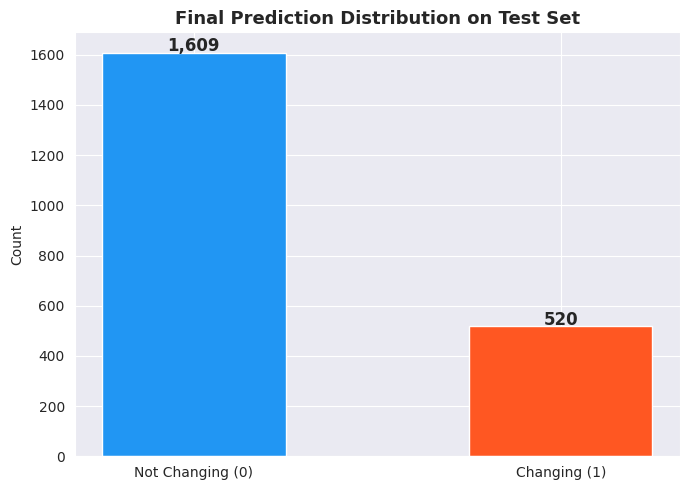

In [62]:
# ── Save Predictions ─────────────────────────────────────────────────────────
submission.to_csv('employee_retention_predictions.csv', index=False)
print('Predictions saved to employee_retention_predictions.csv')

# ── Final Prediction Bar Chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
pred_counts = submission['Prediction'].value_counts().sort_index()
bars = ax.bar(['Not Changing (0)', 'Changing (1)'], pred_counts.values,
              color=['#2196F3', '#FF5722'], edgecolor='white', width=0.5)
for bar, val in zip(bars, pred_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,}', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Final Prediction Distribution on Test Set',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()